In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competicao-tcc-ia-2025/base_teste.csv
/kaggle/input/competicao-tcc-ia-2025/base_treinamento.csv
/kaggle/input/competicao-tcc-ia-2025/exemplo_submisso.csv


In [3]:
!pip install --upgrade scikit-learn imbalanced-learn

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

# 1. Carregar dados
train = pd.read_csv('/kaggle/input/competicao-tcc-ia-2025/base_treinamento.csv')
test = pd.read_csv('/kaggle/input/competicao-tcc-ia-2025/base_teste.csv')

X = train.drop(columns=['target', 'id'])
y = train['target']
X_test = test.drop(columns=['id'])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Modelos
models = {
    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        tree_method='gpu_hist',
        predictor='gpu_predictor',
        verbosity=0
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
}

# 3. Técnicas de balanceamento
balance_methods = {
    'No Balancing': None,
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
    'RandomOverSampler': RandomOverSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
}

# 4. Scale_pos_weight para XGBoost
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
print(f"Scale pos weight calculado para XGBoost: {scale_pos_weight:.2f}")

# 5. Loop principal
results = []

for model_name, model in models.items():
    for bal_name, sampler in balance_methods.items():
        print(f"\n=== {model_name} + {bal_name} ===")

        # Usar scale_pos_weight se for XGBoost sem sampler
        if model_name == 'XGBoost' and bal_name == 'No Balancing':
            model.set_params(scale_pos_weight=scale_pos_weight)

        steps = [
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]
        if sampler is not None:
            steps.append(('sampler', sampler))
        steps.append(('model', model))

        pipeline = ImbPipeline(steps)

        # cross_val_predict para prever rótulos e probabilidades
        y_pred = cross_val_predict(pipeline, X, y, cv=cv, method='predict', n_jobs=-1)
        y_proba = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

        # Métricas
        auc = roc_auc_score(y, y_proba)
        acc = accuracy_score(y, y_pred)
        prec = precision_score(y, y_pred, zero_division=0)
        rec = recall_score(y, y_pred)
        f1 = f1_score(y, y_pred)
        cm = confusion_matrix(y, y_pred)

        # Print detalhado
        print(f"AUC ROC     : {auc:.4f}")
        print(f"Acurácia    : {acc:.4f}")
        print(f"Precisão    : {prec:.4f}")
        print(f"Recall      : {rec:.4f}")
        print(f"F1 Score    : {f1:.4f}")
        print(f"Matriz Confusão:\n{cm}")

        results.append({
            'Model': model_name,
            'Balancing': bal_name,
            'AUC': auc,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1
        })

# 6. Resultados ordenados por AUC
df_results = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
print("\n=== Resumo dos Resultados ===")
print(df_results.reset_index(drop=True))

# 7. Salvar em CSV
df_results.to_csv('resultados_modelos_balanceamento.csv', index=False)
print("Arquivo 'resultados_modelos_balanceamento.csv' salvo com sucesso!")

Scale pos weight calculado para XGBoost: 66.16

=== XGBoost + No Balancing ===
AUC ROC     : 0.6570
Acurácia    : 0.7888
Precisão    : 0.0305
Recall      : 0.4277
F1 Score    : 0.0569
Matriz Confusão:
[[288517  74727]
 [  3142   2348]]

=== XGBoost + RandomUnderSampler ===
AUC ROC     : 0.6202
Acurácia    : 0.0261
Precisão    : 0.0150
Recall      : 0.9944
F1 Score    : 0.0295
Matriz Confusão:
[[  4175 359069]
 [    31   5459]]

=== XGBoost + RandomOverSampler ===
AUC ROC     : 0.5711
Acurácia    : 0.0658
Precisão    : 0.0150
Recall      : 0.9546
F1 Score    : 0.0295
Matriz Confusão:
[[ 19019 344225]
 [   249   5241]]

=== XGBoost + SMOTE ===
AUC ROC     : 0.5885
Acurácia    : 0.3473
Precisão    : 0.0171
Recall      : 0.7576
F1 Score    : 0.0334
Matriz Confusão:
[[123887 239357]
 [  1331   4159]]

=== RandomForest + No Balancing ===
AUC ROC     : 0.6332
Acurácia    : 0.9851
Precisão    : 0.0000
Recall      : 0.0000
F1 Score    : 0.0000
Matriz Confusão:
[[363244      0]
 [  5490      0]]

In [1]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar dados
train = pd.read_csv('/kaggle/input/competicao-tcc-ia-2025/base_treinamento.csv')
test = pd.read_csv('/kaggle/input/competicao-tcc-ia-2025/base_teste.csv')

X = train.drop(columns=['target', 'id'])
y = train['target']
X_test = test.drop(columns=['id'])

# 2. Separar treino e validação
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Calcular scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# 4. Pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=70)),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        tree_method='gpu_hist',
        predictor='gpu_predictor',
        verbosity=0
    ))
])

# 5. Espaço de busca (Grade enxuta)
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5],
    'model__reg_alpha': [0, 1],
    'model__reg_lambda': [1, 2]
}

# 6. GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# 7. Treinar busca
grid_search.fit(X_train, y_train)

# 8. Predição e avaliação
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)
y_proba = best_model.predict_proba(X_val)[:, 1]

print("\n=== Melhor combinação de hiperparâmetros ===")
print(grid_search.best_params_)

print("\n=== Avaliação na validação ===")
print(f"AUC ROC     : {roc_auc_score(y_val, y_proba):.4f}")
print(f"Acurácia    : {accuracy_score(y_val, y_pred):.4f}")
print(f"Precisão    : {precision_score(y_val, y_pred):.4f}")
print(f"Recall      : {recall_score(y_val, y_pred):.4f}")
print(f"F1 Score    : {f1_score(y_val, y_pred):.4f}")


scale_pos_weight = 66.16
Fitting 3 folds for each of 48 candidates, totalling 144 fits

=== Melhor combinação de hiperparâmetros ===
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__reg_alpha': 1, 'model__reg_lambda': 2}

=== Avaliação na validação ===
AUC ROC     : 0.6292
Acurácia    : 0.6950
Precisão    : 0.0235
Recall      : 0.4809
F1 Score    : 0.0448


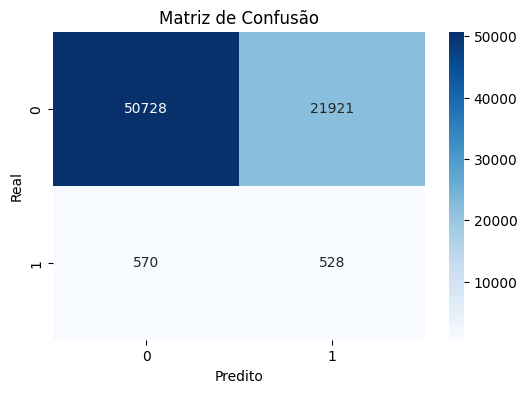

In [3]:
# 9. Matriz de confusão
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [4]:
# 10. Salvar melhores resultados no CSV
resultados = {
    'AUC ROC': roc_auc_score(y_val, y_proba),
    'Acurácia': accuracy_score(y_val, y_pred),
    'Precisão': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'F1 Score': f1_score(y_val, y_pred),
}

# Unir métricas com os melhores parâmetros
melhor_resultado = {**grid_search.best_params_, **resultados}

# Criar DataFrame
df_resultados = pd.DataFrame([melhor_resultado])

# Salvar em CSV
df_resultados.to_csv("melhores_resultados.csv", index=False)

print("\nResultados salvos em 'melhores_resultados.csv'")



Resultados salvos em 'melhores_resultados.csv'
